# Wheat Plant Disease Classification: Comparative Study

This notebook compares transfer learning performance of VGG16, MobileNetV2, and ResNet50 on the Kaggle Wheat Plant Diseases dataset, using accuracy, precision, recall, and F1-score.


## Setup

Requirements
- Python 3.9+
- TensorFlow 2.13+
- scikit-learn, pandas, matplotlib, seaborn
- Kaggle API credentials

Install dependencies
- `pip install -r requirements.txt`

Kaggle credentials
1. Create a Kaggle API token (kaggle.json).
2. Place it at ~/.kaggle/kaggle.json or set environment variables KAGGLE_USERNAME and KAGGLE_KEY.


In [3]:
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight


## Training Strategy

Each pretrained CNN is trained in two stages: first as a fixed feature extractor, then with the final convolutional layers fine-tuned at a low learning rate.
Batch-normalization layers remain frozen during fine-tuning to preserve stable ImageNet statistics.

Resume option: set `RESUME_FROM_CHECKPOINT = True` to evaluate saved checkpoints without retraining in `artifacts/`.

Leave resume disabled when generating training and fine-tuning plots; those require histories from this run.

Key hyperparameters to tune if needed: `INITIAL_EPOCHS`, `INITIAL_LR`, `FINE_TUNE_EPOCHS`, `FINE_TUNE_LR`, and `PATIENCE`.


In [4]:
SEED = 42
IMG_SIZE = 224
BATCH_SIZE = 32

# Training hyperparameters
INITIAL_EPOCHS = 35
INITIAL_LR = 3e-4
FINE_TUNE_EPOCHS = 10
FINE_TUNE_LR = 3e-6
FINE_TUNE_LAYERS = 15  # A smaller unfreeze range reduces overfitting
PATIENCE = 6
L2_WEIGHT_DECAY = 1e-4
RESUME_FROM_CHECKPOINT = False  # set True to evaluate existing checkpoints without retraining
AUTOTUNE = tf.data.AUTOTUNE

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

set_seed()

print('TensorFlow:', tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
print('GPUs:', gpus)
for gpu in gpus:
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except Exception as exc:
        print('Could not set memory growth:', exc)


TensorFlow: 2.21.0
GPUs: []


In [5]:
import json

DATA_DIR = Path('data')
DATA_ROOT = DATA_DIR / 'Wheat Disease Dataset'

IMAGE_EXTS = {'.jpg', '.jpeg', '.png', '.jfif'}

def has_images(path):
    return any(p.suffix.lower() in IMAGE_EXTS for p in path.iterdir() if p.is_file())

def find_image_root(base_dir):
    base_dir = Path(base_dir)
    for p in [base_dir] + list(base_dir.rglob('*')):
        if not p.is_dir():
            continue
        subdirs = [d for d in p.iterdir() if d.is_dir() and d.name.lower() != 'augmented']
        if not subdirs:
            continue
        if all(has_images(d) for d in subdirs):
            return p
    raise FileNotFoundError('Could not find an image root with class subfolders.')


try:
    data_root = find_image_root(DATA_ROOT if DATA_ROOT.is_dir() else DATA_DIR)
    print('Image root:', data_root.resolve())
except FileNotFoundError as exc:
    raise FileNotFoundError(
        f'No dataset found under {DATA_DIR.resolve()}. '
        'Place class folders under data/Wheat Disease Dataset.'
    ) from exc


Image root: C:\Users\it\Desktop\wheat\data\Wheat Disease Dataset


In [9]:
merge_map = {
    # Keep YellowRust as a separate class for augmented data
}

raw_classes = sorted([d.name for d in data_root.iterdir() if d.is_dir() and d.name.lower() != 'augmented'])
print('Raw classes:', raw_classes)

class_names = sorted({merge_map.get(name, name) for name in raw_classes})
print('Classes:', class_names)

# Save class names for inference apps
ARTIFACTS_DIR = Path('artifacts')
ARTIFACTS_DIR.mkdir(exist_ok=True)
(ARTIFACTS_DIR / 'class_names.json').write_text(json.dumps(class_names, indent=2))

Raw classes: ['BrownRust', 'Healthy', 'Mildew', 'Septoria', 'YellowRust']
Classes: ['BrownRust', 'Healthy', 'Mildew', 'Septoria', 'YellowRust']


72

In [10]:
image_paths = []
labels = []
class_to_index = {name: i for i, name in enumerate(class_names)}
bad_files = []

for cls in raw_classes:
    target_cls = merge_map.get(cls, cls)
    for p in (data_root / cls).rglob('*'):
        if p.suffix.lower() in IMAGE_EXTS:
            try:
                img_bytes = tf.io.read_file(str(p))
                _ = tf.image.decode_image(img_bytes, channels=3, expand_animations=False)
                image_paths.append(str(p))
                labels.append(class_to_index[target_cls])
            except Exception:
                bad_files.append(str(p))

print('Total images:', len(image_paths))
print('Unreadable images:', len(bad_files))

label_map = {v: k for k, v in class_to_index.items()}
df = pd.DataFrame({'path': image_paths, 'label': labels})
df['class'] = df['label'].map(label_map)
display(df['class'].value_counts())


Total images: 5952
Unreadable images: 0


class
Septoria      1479
Mildew        1174
BrownRust     1159
YellowRust    1097
Healthy       1043
Name: count, dtype: int64

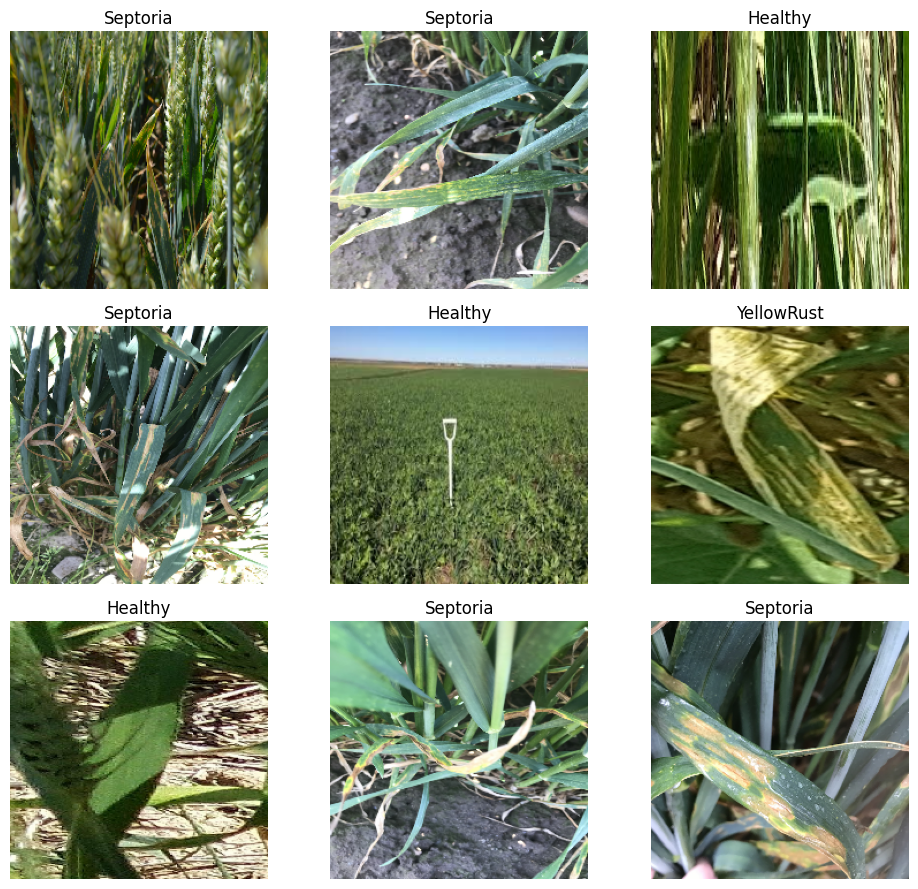

In [11]:
def show_samples(df, n=9):
    samples = df.sample(min(n, len(df)), random_state=SEED)
    rows = int(np.ceil(n / 3))
    plt.figure(figsize=(10, 3 * rows))
    for i, (_, row) in enumerate(samples.iterrows()):
        img = tf.io.read_file(row['path'])
        img = tf.image.decode_image(img, channels=3, expand_animations=False)
        img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
        plt.subplot(rows, 3, i + 1)
        plt.imshow(tf.cast(img, tf.uint8))
        plt.title(row['class'])
        plt.axis('off')
    plt.tight_layout()

show_samples(df, n=9)


In [12]:
# Use .to_numpy() to ensure compatibility with sklearn
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    df['path'].to_numpy(),    # Changed from .values
    df['label'].to_numpy(),   # Changed from .values
    test_size=0.3,
    stratify=df['label'].to_numpy(), # Changed from .values
    random_state=SEED,
)

val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths,
    temp_labels,
    test_size=0.5,
    stratify=temp_labels,
    random_state=SEED,
)
print('Train/Val/Test:', len(train_paths), len(val_paths), len(test_paths))


Train/Val/Test: 4166 893 893


In [13]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomTranslation(0.05, 0.05),
    tf.keras.layers.RandomContrast(0.1),
], name='augmentation')


def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32)
    return img, label


def augment_image(img, label):
    # Applied only to training images; validation and test images stay unchanged.
    return data_augmentation(img, training=True), label


def make_dataset(paths, labels, training=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        ds = ds.shuffle(buffer_size=len(paths), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)
    if training:
        ds = ds.map(augment_image, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds


train_ds = make_dataset(train_paths, train_labels, training=True)
val_ds = make_dataset(val_paths, val_labels, training=False)
test_ds = make_dataset(test_paths, test_labels, training=False)


In [15]:
# Optional: Offline Data Augmentation (Disabled by default)
# Note: Real-time data augmentation is already active in Cell 10 via tf.data.
# Saving augmented copies to disk is unnecessary and can cause dataset contamination.

SAVE_OFFLINE_AUGMENTED = False

if SAVE_OFFLINE_AUGMENTED:
    import shutil
    AUGMENTED_DIR = DATA_DIR / "augmented"
    AUGMENTED_DIR.mkdir(parents=True, exist_ok=True)

    def generate_and_save_augmented_data(image_paths, labels, class_names, output_dir, augmentations_per_image=3, dataset_type='train'):
        """
        Generate augmented images and save them to separate folders by class.
        """
        dataset_dir = output_dir / dataset_type
        if dataset_dir.exists():
            shutil.rmtree(dataset_dir)
        dataset_dir.mkdir(parents=True, exist_ok=True)

        for class_idx, class_name in enumerate(class_names):
            class_dir = dataset_dir / class_name
            class_dir.mkdir(parents=True, exist_ok=True)

        print(f'Saving augmented {dataset_type} data...')

        for img_idx, (path, label) in enumerate(zip(image_paths, labels)):
            class_name = class_names[label]
            class_dir = dataset_dir / class_name

            img = tf.io.read_file(str(path))
            img = tf.image.decode_image(img, channels=3, expand_animations=False)
            img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
            img = tf.cast(img, tf.float32)

            for aug_idx in range(augmentations_per_image):
                augmented_img = data_augmentation(tf.expand_dims(img, 0), training=True)[0]
                augmented_img = tf.clip_by_value(augmented_img, 0, 255)
                augmented_img = tf.cast(augmented_img, tf.uint8)

                original_name = Path(path).stem
                output_filename = f'{original_name}_aug_{aug_idx}.jpg'
                output_path = class_dir / output_filename
                tf.keras.preprocessing.image.save_img(str(output_path), augmented_img.numpy())

            if (img_idx + 1) % max(1, len(image_paths) // 10) == 0:
                print(f'  Processed {img_idx + 1}/{len(image_paths)} images...')

        print(f'[OK] Augmented {dataset_type} data saved to: {dataset_dir}')
else:
    print("Offline disk augmentation is disabled. On-the-fly augmentation is active in Cell 10.")

Offline disk augmentation is disabled. On-the-fly augmentation is active in Cell 10.


In [16]:
class_weights_arr = compute_class_weight(class_weight='balanced', classes=np.unique(train_labels), y=train_labels)
class_weights = {i: w for i, w in enumerate(class_weights_arr)}
class_weights


{0: np.float64(1.0273736128236746),
 1: np.float64(1.1413698630136986),
 2: np.float64(1.013625304136253),
 3: np.float64(0.8050241545893719),
 4: np.float64(1.0848958333333334)}

In [17]:
def build_model(base_name, base_fn, preprocess_fn, num_classes):
    inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = preprocess_fn(inputs)
    base = base_fn(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
    base.trainable = False
    x = base(x, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)

    # Regularized classification head to reduce overfitting
    regularizer = tf.keras.regularizers.l2(L2_WEIGHT_DECAY)
    x = tf.keras.layers.Dense(512, activation='relu', kernel_regularizer=regularizer)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.5)(x)

    x = tf.keras.layers.Dense(256, activation='relu', kernel_regularizer=regularizer)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.4)(x)

    outputs = tf.keras.layers.Dense(num_classes, activation='softmax', kernel_regularizer=regularizer)(x)
    model = tf.keras.Model(inputs, outputs, name=f'{base_name}_transfer')

    # SparseCategoricalCrossentropy in this Keras version does not accept label_smoothing.
    loss_fn = tf.keras.losses.SparseCategoricalCrossentropy()

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=INITIAL_LR),
        loss=loss_fn,
        metrics=['accuracy'],
    )
    return model, base


In [18]:
def train_head_only(
    model,
    train_ds,
    val_ds,
    class_weights,
    initial_epochs=INITIAL_EPOCHS,
    initial_lr=INITIAL_LR,
    patience=PATIENCE,
    checkpoint_path=None,
):
    callbacks = [
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=patience, min_delta=0.001, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=max(2, patience//2), min_lr=1e-6),
    ]

    if checkpoint_path is not None:
        callbacks.append(
            tf.keras.callbacks.ModelCheckpoint(
                filepath=str(checkpoint_path),
                monitor='val_loss',
                save_best_only=True,
                save_weights_only=False,
                verbose=1,
            )
        )

    # Train only the classifier head (base remains frozen)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=initial_lr),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=['accuracy'],
    )

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=initial_epochs,
        class_weight=class_weights,
        callbacks=callbacks,
        verbose=1,
    )

    return history


def fine_tune_model(
    model,
    train_ds,
    val_ds,
    class_weights,
    fine_tune_layers=FINE_TUNE_LAYERS,
    fine_tune_epochs=FINE_TUNE_EPOCHS,
    fine_tune_lr=FINE_TUNE_LR,
    patience=PATIENCE,
    checkpoint_path=None,
):
    """Fine-tune the final convolutional layers without updating BatchNorm statistics."""
    backbone = next((layer for layer in model.layers if isinstance(layer, tf.keras.Model)), None)
    if backbone is None:
        raise ValueError('Could not locate the pretrained backbone in the model.')

    backbone.trainable = True
    for layer in backbone.layers[:-fine_tune_layers]:
        layer.trainable = False
    for layer in backbone.layers[-fine_tune_layers:]:
        layer.trainable = not isinstance(layer, tf.keras.layers.BatchNormalization)

    callbacks = [
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=patience, min_delta=0.001, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=max(2, patience // 2), min_lr=1e-7),
    ]
    if checkpoint_path is not None:
        callbacks.append(tf.keras.callbacks.ModelCheckpoint(
            filepath=str(checkpoint_path), monitor='val_loss', save_best_only=True, verbose=1
        ))

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=fine_tune_lr),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=['accuracy'],
    )
    print(f'Fine-tuning the last {fine_tune_layers} layers of {backbone.name} at lr={fine_tune_lr}')
    return model.fit(
        train_ds, validation_data=val_ds, epochs=fine_tune_epochs,
        class_weight=class_weights, callbacks=callbacks, verbose=1
    )


In [19]:
# RESUME_FROM_CHECKPOINT is configured in the setup cell above.


In [20]:
# Checkpoints are loaded by the training loop when resume mode is enabled.


In [21]:
model_configs = {
    'VGG16': (tf.keras.applications.VGG16, tf.keras.applications.vgg16.preprocess_input),
    'MobileNetV2': (tf.keras.applications.MobileNetV2, tf.keras.applications.mobilenet_v2.preprocess_input),
    'ResNet50': (tf.keras.applications.ResNet50, tf.keras.applications.resnet50.preprocess_input),
}

results = []
histories = {}
fine_tune_histories = {}
saved_paths = {}


num_classes = len(class_names)



In [22]:
for name, (base_fn, preprocess_fn) in model_configs.items():
    tf.keras.backend.clear_session()
    print(f'Training {name} (base frozen)')

    head_ckpt_path = ARTIFACTS_DIR / f'{name}_head_best.keras'
    ckpt_path = ARTIFACTS_DIR / f'{name}_best.keras'
    model = None

    # A completed fine-tuned checkpoint can be used directly.
    if RESUME_FROM_CHECKPOINT and ckpt_path.exists():
        loaded_model = tf.keras.models.load_model(ckpt_path)
        if loaded_model.output_shape[-1] == num_classes:
            print(f'Using fine-tuned checkpoint: {ckpt_path}')
            model = loaded_model

    if model is None:
        model, _base = build_model(name, base_fn, preprocess_fn, num_classes)
        history = train_head_only(
            model, train_ds, val_ds, class_weights, checkpoint_path=head_ckpt_path
        )
        histories[name] = history

        # Fine-tune from the best feature-extractor checkpoint.
        if head_ckpt_path.exists():
            model = tf.keras.models.load_model(head_ckpt_path)
        fine_tune_history = fine_tune_model(
            model, train_ds, val_ds, class_weights, checkpoint_path=ckpt_path
        )
        fine_tune_histories[name] = fine_tune_history

    # Evaluate the best fine-tuned model.
    if ckpt_path.exists():
        model = tf.keras.models.load_model(ckpt_path)

    y_prob = model.predict(test_ds)
    y_pred = np.argmax(y_prob, axis=1)
    y_true = np.array(test_labels)

    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted', zero_division=0)

    results.append({
        'model': name,
        'accuracy': acc,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
    })

    model_path = ARTIFACTS_DIR / f'{name}.keras'
    model.save(model_path)
    saved_paths[name] = model_path
    print(f'Saved: {model_path}')



Training VGG16 (base frozen)
Epoch 1/35
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4542 - loss: 1.7321
Epoch 1: val_loss improved from None to 0.66060, saving model to artifacts\VGG16_head_best.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 391s 3s/step - accuracy: 0.5718 - loss: 1.3417 - val_accuracy: 0.8029 - val_loss: 0.6606 - learning_rate: 3.0000e-04
Epoch 2/35
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7033 - loss: 0.9353
Epoch 2: val_loss improved from 0.66060 to 0.59251, saving model to artifacts\VGG16_head_best.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 388s 3s/step - accuracy: 0.7199 - loss: 0.8874 - val_accuracy: 0.8309 - val_loss: 0.5925 - learning_rate: 3.0000e-04
Epoch 3/35
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7554 - loss: 0.7736
Epoch 3: val_loss improved from 0.59251 to 0.57919, saving model to artifacts\VGG16_head_best.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 387s 3s/step - accuracy: 0.7585 - loss: 0.7685 - val_accuracy: 0.8421 - val_loss: 0.5792 - learni

In [38]:
results_df = pd.DataFrame(results)
print(results_df.columns)
results_df


Index(['model', 'accuracy', 'precision', 'recall', 'f1_score'], dtype='object')


,model,accuracy,precision,recall,f1_score
0,VGG16,0.939530,0.942575,0.939530,0.939507
1,MobileNetV2,0.896976,0.904865,0.896976,0.897699
2,ResNet50,0.917133,0.923943,0.917133,0.918304


In [24]:
train_val_results = []
for name, hist in histories.items():
    h = hist.history
    train_acc = h.get('accuracy', [None])[-1]
    val_acc = h.get('val_accuracy', [None])[-1]
    best_val_epoch = int(np.argmax(h['val_accuracy'])) + 1 if 'val_accuracy' in h else None
    best_val_acc = float(max(h['val_accuracy'])) if 'val_accuracy' in h else None
    train_val_results.append({
        'model': name,
        'train_accuracy_last_epoch': train_acc,
        'val_accuracy_last_epoch': val_acc,
        'best_val_accuracy': best_val_acc,
        'best_val_epoch': best_val_epoch,
    })

train_val_df = pd.DataFrame(train_val_results).sort_values('model').reset_index(drop=True)
train_val_df

,model,train_accuracy_last_epoch,val_accuracy_last_epoch,best_val_accuracy,best_val_epoch
0,MobileNetV2,0.914786,0.914894,0.914894,15
1,ResNet50,0.925588,0.931691,0.937290,5
2,VGG16,0.899184,0.923852,0.923852,27


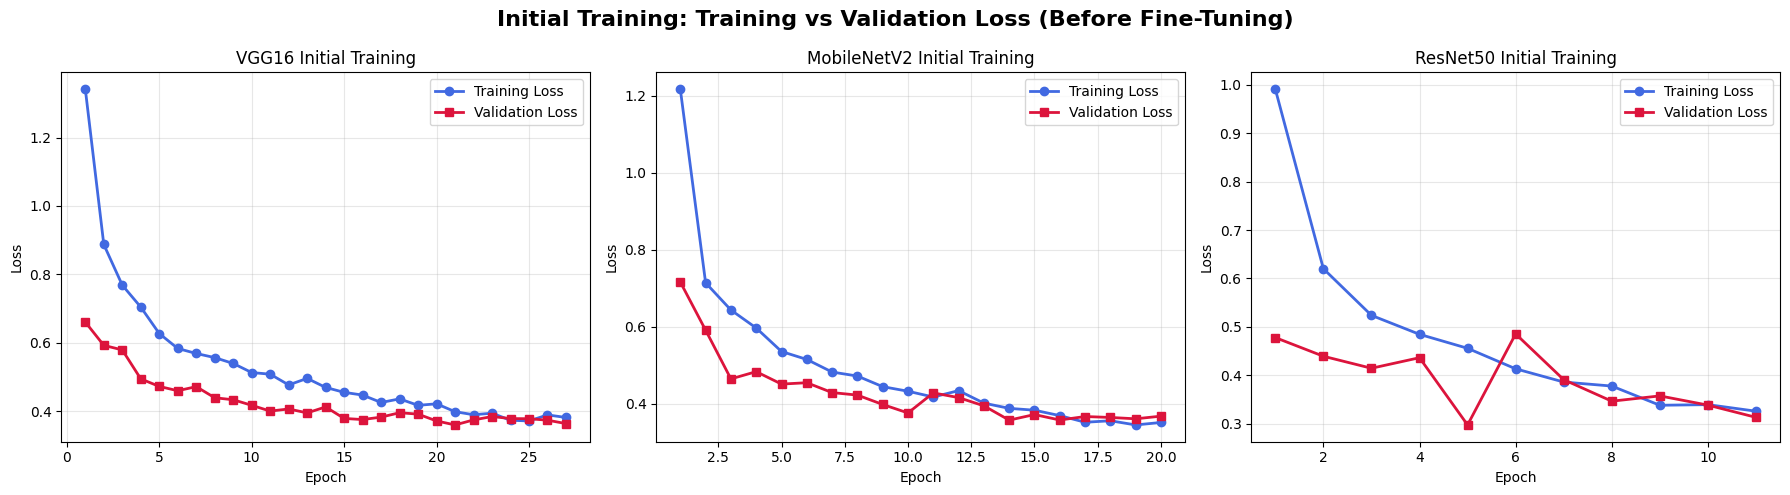

In [25]:
# Initial training phase (without fine-tuning): training vs validation loss
model_order = ['VGG16', 'MobileNetV2', 'ResNet50']
missing_histories = [name for name in model_order if name not in histories]
if missing_histories:
    raise ValueError(
        f'Training histories are missing for: {missing_histories}. Run the training cell first.'
    )

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)
for ax, name in zip(axes, model_order):
    history = histories[name].history
    epochs = range(1, len(history['loss']) + 1)
    ax.plot(epochs, history['loss'], color='royalblue', marker='o', linewidth=2, label='Training Loss')
    ax.plot(epochs, history['val_loss'], color='crimson', marker='s', linewidth=2, label='Validation Loss')
    ax.set_title(f'{name} Initial Training')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.grid(True, alpha=0.3)
    ax.legend()

fig.suptitle('Initial Training: Training vs Validation Loss (Before Fine-Tuning)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


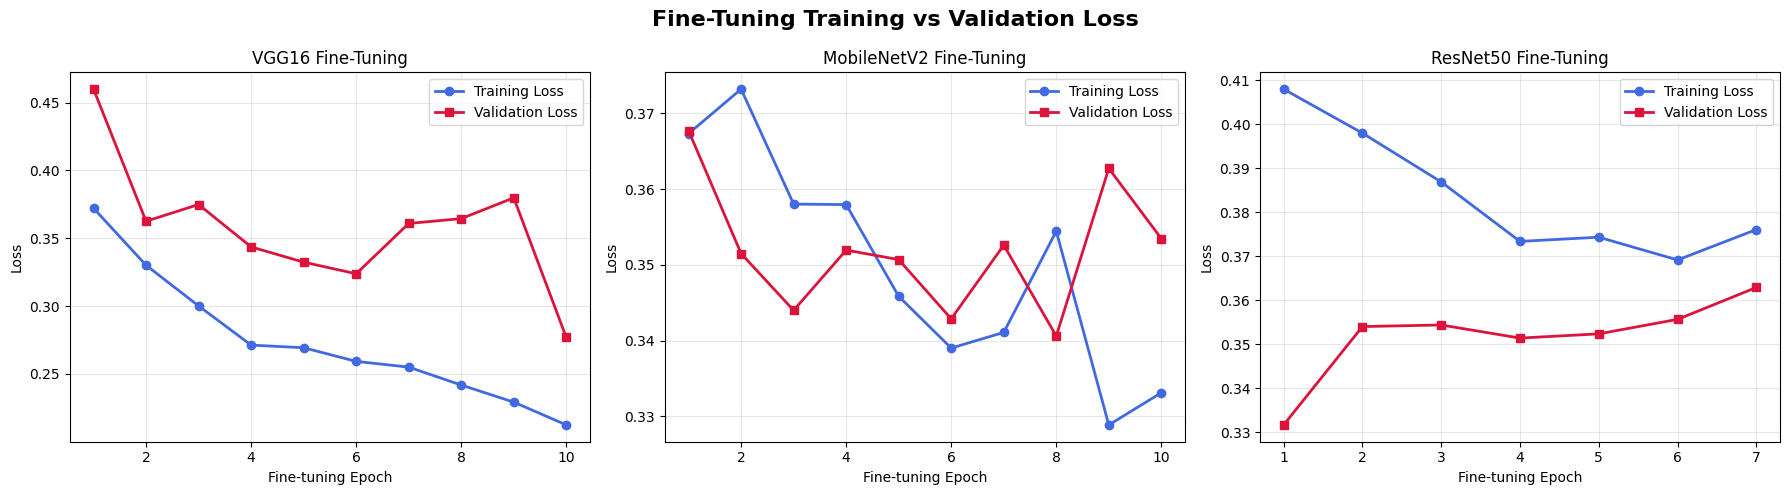

In [26]:
# Fine-tuning phase: training vs validation loss for all models
model_order = ['VGG16', 'MobileNetV2', 'ResNet50']
missing_histories = [name for name in model_order if name not in fine_tune_histories]
if missing_histories:
    raise ValueError(
        f'Fine-tuning histories are missing for: {missing_histories}. '
        'Set RESUME_FROM_CHECKPOINT = False and run the training cell first.'
    )

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)
for ax, name in zip(axes, model_order):
    history = fine_tune_histories[name].history
    epochs = range(1, len(history['loss']) + 1)
    ax.plot(epochs, history['loss'], color='royalblue', marker='o', linewidth=2, label='Training Loss')
    ax.plot(epochs, history['val_loss'], color='crimson', marker='s', linewidth=2, label='Validation Loss')
    ax.set_title(f'{name} Fine-Tuning')
    ax.set_xlabel('Fine-tuning Epoch')
    ax.set_ylabel('Loss')
    ax.grid(True, alpha=0.3)
    ax.legend()

fig.suptitle('Fine-Tuning Training vs Validation Loss', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


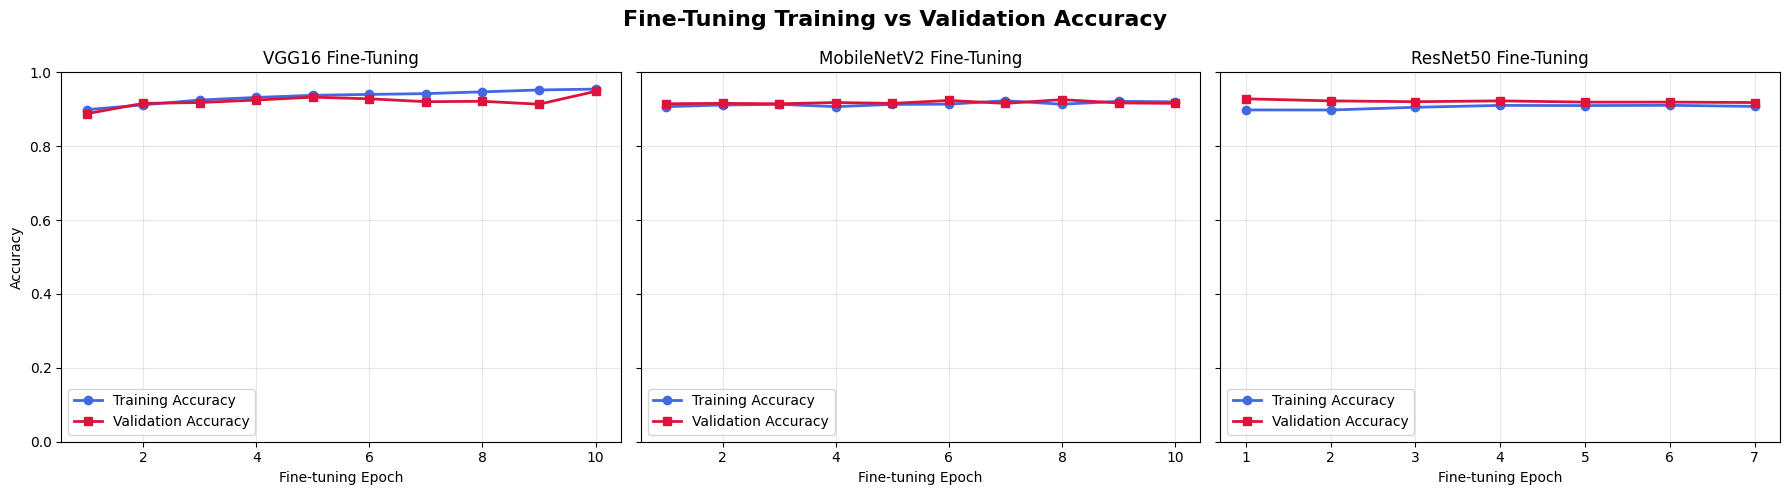

In [40]:
# Fine-tuning phase: training and validation accuracy together for all models
model_order = ['VGG16', 'MobileNetV2', 'ResNet50']
missing_histories = [name for name in model_order if name not in fine_tune_histories]
if missing_histories:
    raise ValueError(
        f'Fine-tuning histories are missing for: {missing_histories}. '
        'Set RESUME_FROM_CHECKPOINT = False and run the training cell first.'
    )

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for ax, name in zip(axes, model_order):
    history = fine_tune_histories[name].history
    epochs = range(1, len(history['accuracy']) + 1)
    ax.plot(epochs, history['accuracy'], color='royalblue', marker='o', linewidth=2, label='Training Accuracy')
    ax.plot(epochs, history['val_accuracy'], color='crimson', marker='s', linewidth=2, label='Validation Accuracy')
    ax.set_title(f'{name} Fine-Tuning')
    ax.set_xlabel('Fine-tuning Epoch')
    ax.set_ylim(0, 1.0)
    ax.grid(True, alpha=0.3)
    ax.legend()

axes[0].set_ylabel('Accuracy')
fig.suptitle('Fine-Tuning Training vs Validation Accuracy', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

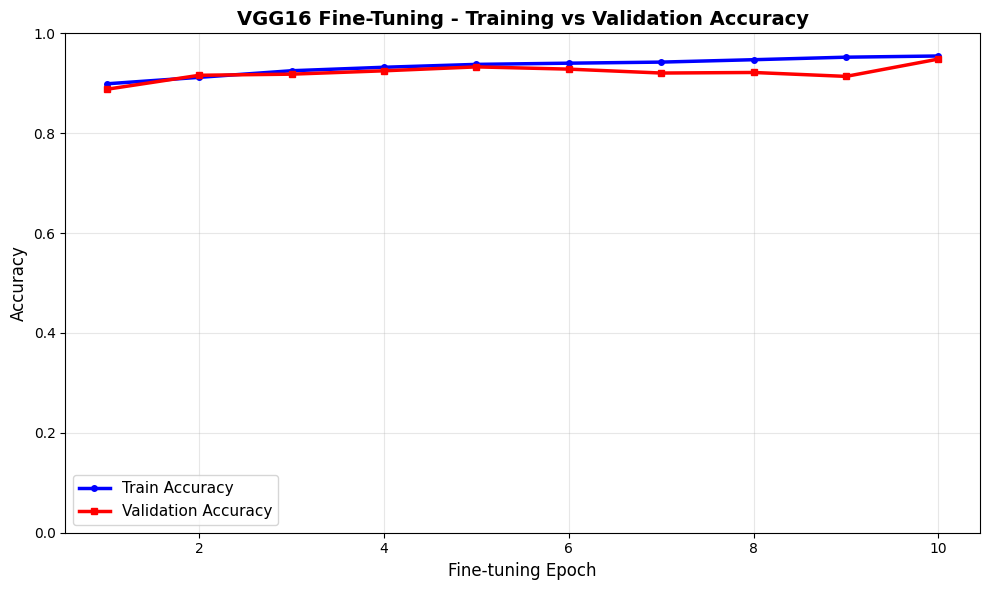

VGG16 fine-tuning - Train Accuracy (last epoch): 0.9546
VGG16 fine-tuning - Validation Accuracy (last epoch): 0.9485
VGG16 fine-tuning - Best Validation Accuracy: 0.9485 at epoch 10


In [41]:
# VGG16 - Fine-Tuning Training vs Validation Accuracy
if 'VGG16' not in fine_tune_histories:
    raise ValueError('VGG16 fine-tuning history is unavailable. Run the training cell with RESUME_FROM_CHECKPOINT = False.')

vgg_hist = fine_tune_histories['VGG16'].history
epochs_vgg = range(1, len(vgg_hist['accuracy']) + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs_vgg, vgg_hist['accuracy'], 'b-', label='Train Accuracy', linewidth=2.5, marker='o', markersize=4)
plt.plot(epochs_vgg, vgg_hist['val_accuracy'], 'r-', label='Validation Accuracy', linewidth=2.5, marker='s', markersize=4)
plt.title('VGG16 Fine-Tuning - Training vs Validation Accuracy', fontsize=14, fontweight='bold')
plt.xlabel('Fine-tuning Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.ylim([0, 1.0])
plt.tight_layout()
plt.show()

print(f"VGG16 fine-tuning - Train Accuracy (last epoch): {vgg_hist['accuracy'][-1]:.4f}")
print(f"VGG16 fine-tuning - Validation Accuracy (last epoch): {vgg_hist['val_accuracy'][-1]:.4f}")
print(f"VGG16 fine-tuning - Best Validation Accuracy: {max(vgg_hist['val_accuracy']):.4f} at epoch {np.argmax(vgg_hist['val_accuracy']) + 1}")

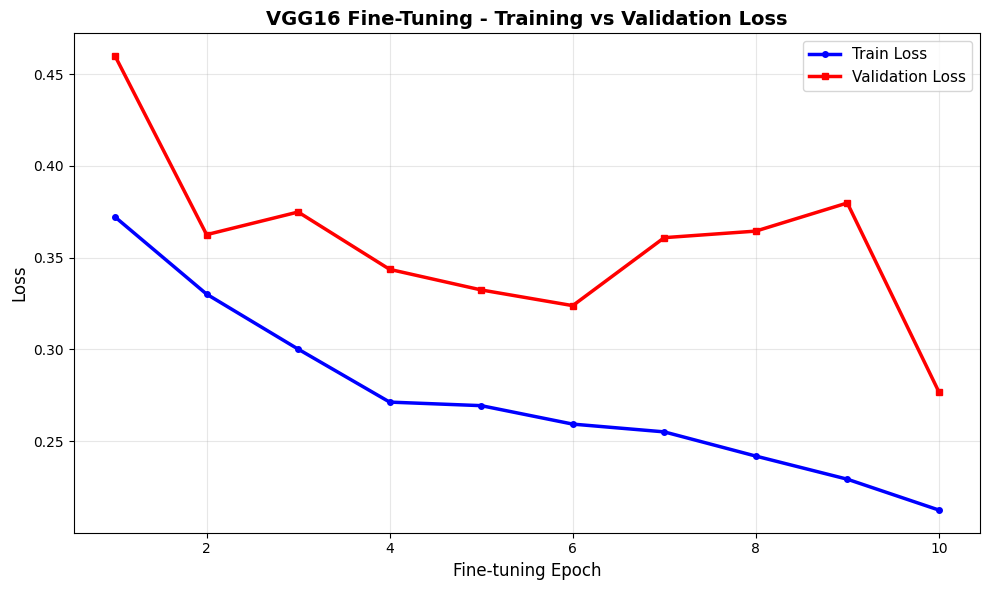

VGG16 fine-tuning - Train Loss (last epoch): 0.2124
VGG16 fine-tuning - Validation Loss (last epoch): 0.2769
VGG16 fine-tuning - Best Validation Loss: 0.2769 at epoch 10


In [43]:
# VGG16 - Fine-Tuning Training vs Validation Loss
if 'VGG16' not in fine_tune_histories:
    raise ValueError('VGG16 fine-tuning history is unavailable. Run the training cell with RESUME_FROM_CHECKPOINT = False.')

vgg_hist = fine_tune_histories['VGG16'].history
epochs_vgg = range(1, len(vgg_hist['loss']) + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs_vgg, vgg_hist['loss'], 'b-', label='Train Loss', linewidth=2.5, marker='o', markersize=4)
plt.plot(epochs_vgg, vgg_hist['val_loss'], 'r-', label='Validation Loss', linewidth=2.5, marker='s', markersize=4)
plt.title('VGG16 Fine-Tuning - Training vs Validation Loss', fontsize=14, fontweight='bold')
plt.xlabel('Fine-tuning Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"VGG16 fine-tuning - Train Loss (last epoch): {vgg_hist['loss'][-1]:.4f}")
print(f"VGG16 fine-tuning - Validation Loss (last epoch): {vgg_hist['val_loss'][-1]:.4f}")
print(f"VGG16 fine-tuning - Best Validation Loss: {min(vgg_hist['val_loss']):.4f} at epoch {np.argmin(vgg_hist['val_loss']) + 1}")


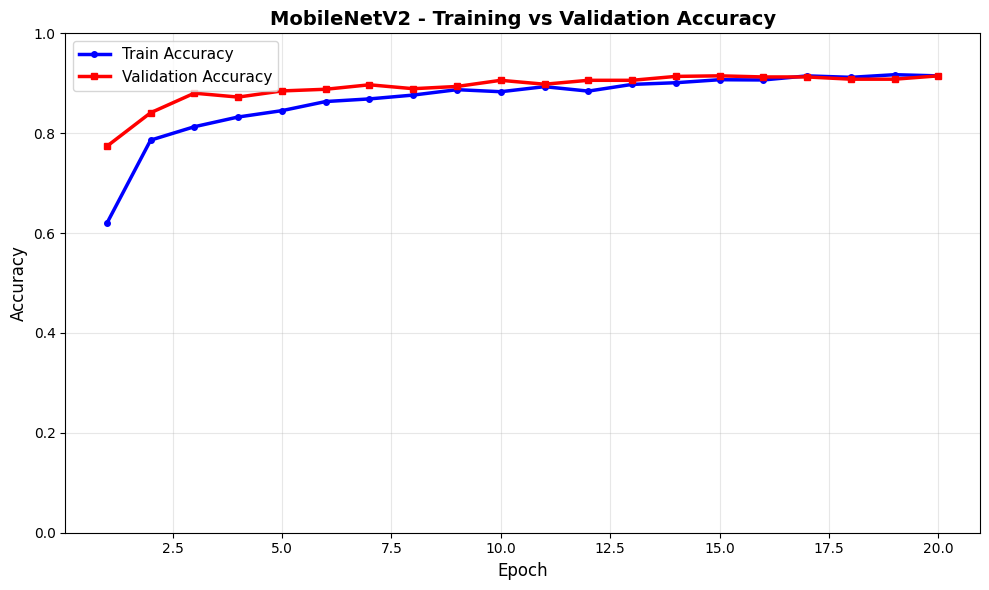

MobileNetV2 - Train Accuracy (last epoch): 0.9148
MobileNetV2 - Validation Accuracy (last epoch): 0.9149
MobileNetV2 - Best Validation Accuracy: 0.9149 at epoch 15


In [49]:
# MobileNetV2 - Train and Validation Accuracy
mobile_hist = histories['MobileNetV2'].history
epochs_mobile = range(1, len(mobile_hist['accuracy']) + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs_mobile, mobile_hist['accuracy'], 'b-', label='Train Accuracy', linewidth=2.5, marker='o', markersize=4)
plt.plot(epochs_mobile, mobile_hist['val_accuracy'], 'r-', label='Validation Accuracy', linewidth=2.5, marker='s', markersize=4)
plt.title('MobileNetV2 - Training vs Validation Accuracy', fontsize=14, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.ylim([0, 1.0])
plt.tight_layout()
plt.show()

print(f"MobileNetV2 - Train Accuracy (last epoch): {mobile_hist['accuracy'][-1]:.4f}")
print(f"MobileNetV2 - Validation Accuracy (last epoch): {mobile_hist['val_accuracy'][-1]:.4f}")
print(f"MobileNetV2 - Best Validation Accuracy: {max(mobile_hist['val_accuracy']):.4f} at epoch {np.argmax(mobile_hist['val_accuracy']) + 1}")

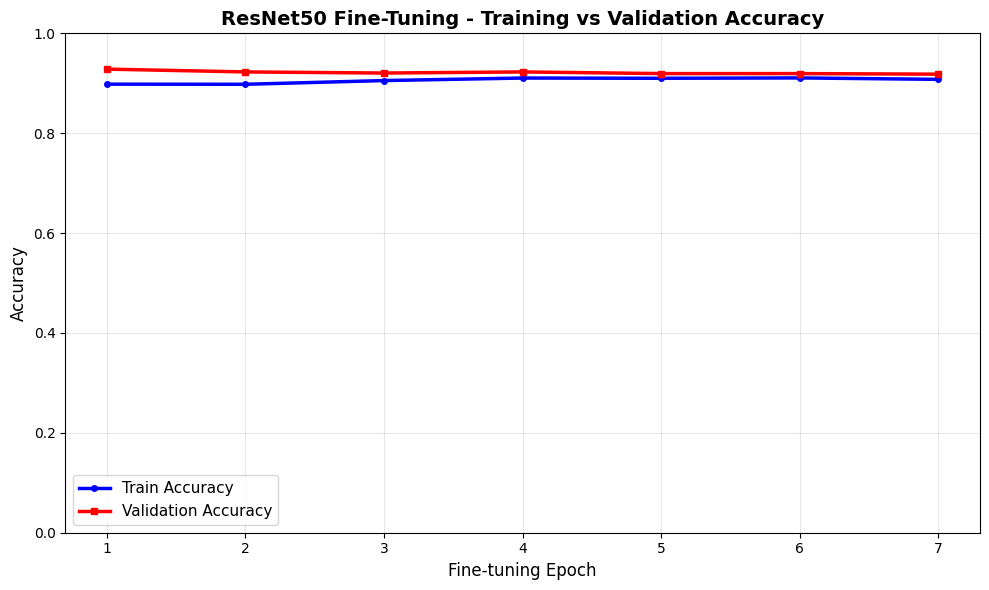

ResNet50 fine-tuning - Train Accuracy (last epoch): 0.9078
ResNet50 fine-tuning - Validation Accuracy (last epoch): 0.9183
ResNet50 fine-tuning - Best Validation Accuracy: 0.9283 at epoch 1


In [50]:
# ResNet50 - Fine-Tuning Training vs Validation Accuracy
if 'ResNet50' not in fine_tune_histories:
    raise ValueError('ResNet50 fine-tuning history is unavailable. Run the training cell with RESUME_FROM_CHECKPOINT = False.')

resnet_hist = fine_tune_histories['ResNet50'].history
epochs_resnet = range(1, len(resnet_hist['accuracy']) + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs_resnet, resnet_hist['accuracy'], 'b-', label='Train Accuracy', linewidth=2.5, marker='o', markersize=4)
plt.plot(epochs_resnet, resnet_hist['val_accuracy'], 'r-', label='Validation Accuracy', linewidth=2.5, marker='s', markersize=4)
plt.title('ResNet50 Fine-Tuning - Training vs Validation Accuracy', fontsize=14, fontweight='bold')
plt.xlabel('Fine-tuning Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.ylim([0, 1.0])
plt.tight_layout()
plt.show()

print(f"ResNet50 fine-tuning - Train Accuracy (last epoch): {resnet_hist['accuracy'][-1]:.4f}")
print(f"ResNet50 fine-tuning - Validation Accuracy (last epoch): {resnet_hist['val_accuracy'][-1]:.4f}")
print(f"ResNet50 fine-tuning - Best Validation Accuracy: {max(resnet_hist['val_accuracy']):.4f} at epoch {np.argmax(resnet_hist['val_accuracy']) + 1}")

In [51]:
histories

{'VGG16': <keras.src.callbacks.history.History at 0x2b4efc0da20>,
 'MobileNetV2': <keras.src.callbacks.history.History at 0x2b49cb371c0>,
 'ResNet50': <keras.src.callbacks.history.History at 0x2b4fe805f60>}

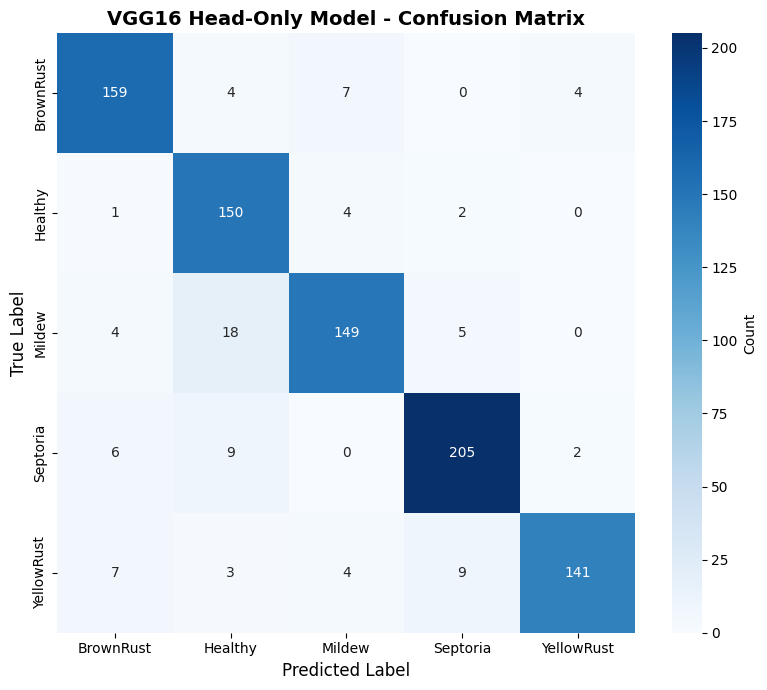

VGG16 Head-Only Model - Classification Report:
              precision    recall  f1-score   support

   BrownRust       0.90      0.91      0.91       174
     Healthy       0.82      0.96      0.88       157
      Mildew       0.91      0.85      0.88       176
    Septoria       0.93      0.92      0.93       222
  YellowRust       0.96      0.86      0.91       164

    accuracy                           0.90       893
   macro avg       0.90      0.90      0.90       893
weighted avg       0.90      0.90      0.90       893



In [47]:
# VGG16 Head-Only Model - Confusion Matrix
# This loads the checkpoint saved before fine-tuning.
vgg_head_only_path = ARTIFACTS_DIR / 'VGG16_head_best.keras'
if not vgg_head_only_path.exists():
    raise FileNotFoundError(
        f'Head-only VGG16 checkpoint not found: {vgg_head_only_path}. Run the head-training stage first.'
    )

vgg_head_only_model = tf.keras.models.load_model(vgg_head_only_path)
y_prob_vgg_head = vgg_head_only_model.predict(test_ds, verbose=0)
y_pred_vgg_head = np.argmax(y_prob_vgg_head, axis=1)
y_true_vgg_head = np.asarray(test_labels)

cm_vgg_head = confusion_matrix(y_true_vgg_head, y_pred_vgg_head)
plt.figure(figsize=(8, 7))
sns.heatmap(
    cm_vgg_head, annot=True, fmt='d', cmap='Blues',
    xticklabels=class_names, yticklabels=class_names, cbar_kws={'label': 'Count'}
)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('VGG16 Head-Only Model - Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('VGG16 Head-Only Model - Classification Report:')
print(classification_report(y_true_vgg_head, y_pred_vgg_head, target_names=class_names, zero_division=0))


28/28 ━━━━━━━━━━━━━━━━━━━━ 70s 2s/step


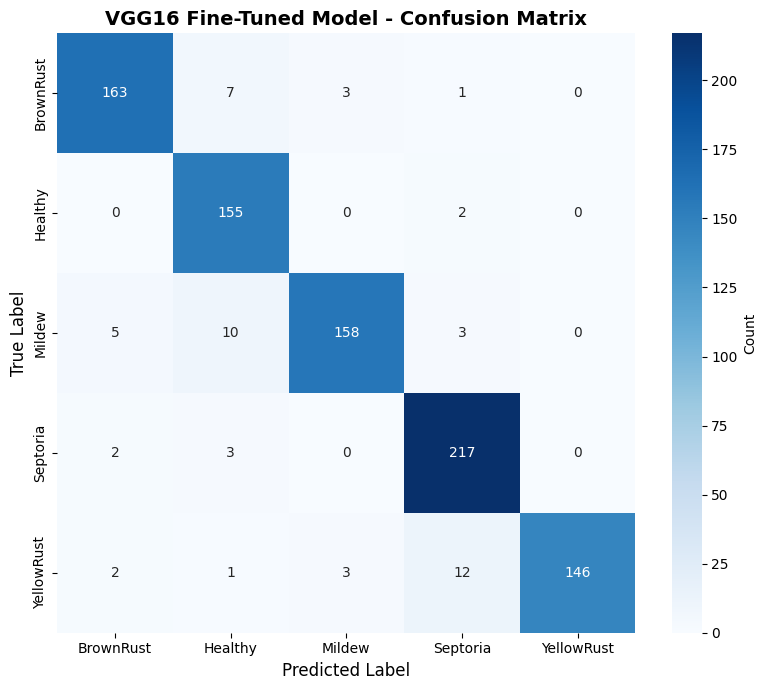

VGG16 Fine-Tuned Model - Classification Report:
              precision    recall  f1-score   support

   BrownRust       0.95      0.94      0.94       174
     Healthy       0.88      0.99      0.93       157
      Mildew       0.96      0.90      0.93       176
    Septoria       0.92      0.98      0.95       222
  YellowRust       1.00      0.89      0.94       164

    accuracy                           0.94       893
   macro avg       0.94      0.94      0.94       893
weighted avg       0.94      0.94      0.94       893



In [48]:
# VGG16 Fine-Tuned Model - Confusion Matrix
vgg_fine_tuned_path = ARTIFACTS_DIR / 'VGG16_best.keras'
if not vgg_fine_tuned_path.exists():
    raise FileNotFoundError(
        f'Fine-tuned VGG16 checkpoint not found: {vgg_fine_tuned_path}. Run the training cell first.'
    )

vgg_model_cm = tf.keras.models.load_model(vgg_fine_tuned_path)
y_prob_vgg = vgg_model_cm.predict(test_ds)
y_pred_vgg = np.argmax(y_prob_vgg, axis=1)
y_true = np.array(test_labels)

cm_vgg = confusion_matrix(y_true, y_pred_vgg)
plt.figure(figsize=(8, 7))
sns.heatmap(cm_vgg, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, cbar_kws={'label': 'Count'})
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('VGG16 Fine-Tuned Model - Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("VGG16 Fine-Tuned Model - Classification Report:")
print(classification_report(y_true, y_pred_vgg, target_names=class_names, zero_division=0))

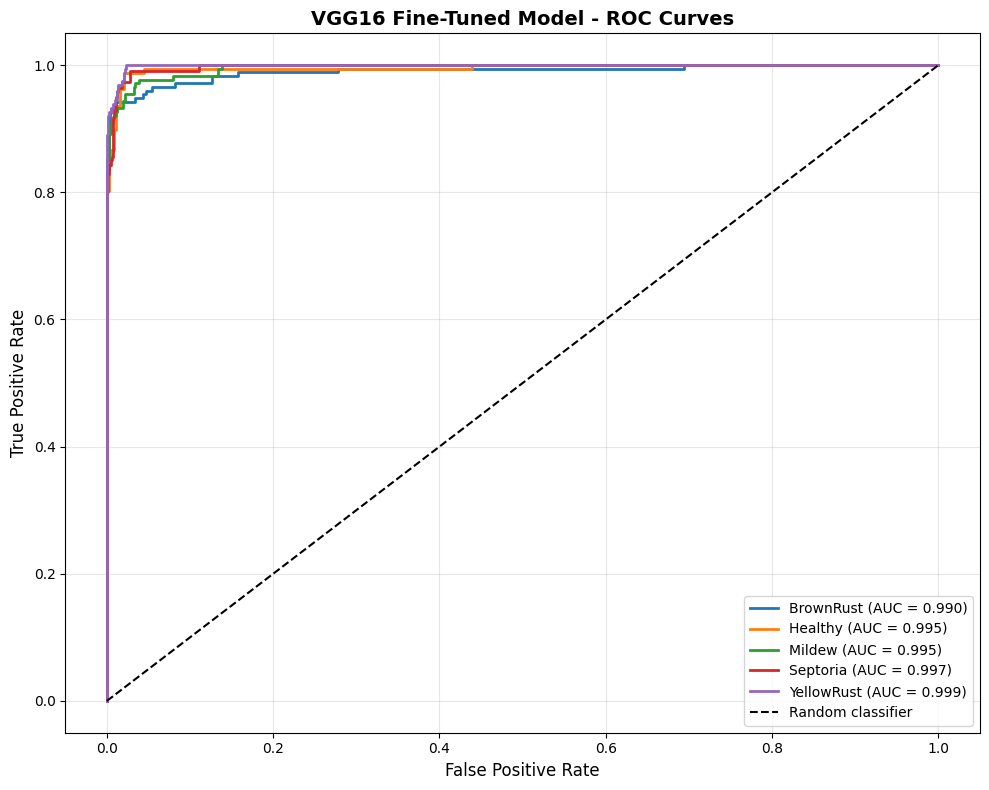

In [53]:
# VGG16 Fine-Tuned Model - ROC Curves (multiclass)
# Use the fine-tuned checkpoint explicitly, not the head-only checkpoint.
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

vgg_fine_tuned_roc_path = ARTIFACTS_DIR / 'VGG16_best.keras'
if not vgg_fine_tuned_roc_path.exists():
    raise FileNotFoundError(
        f'Fine-tuned VGG16 checkpoint not found: {vgg_fine_tuned_roc_path}. Run fine-tuning first.'
    )

vgg_fine_tuned_roc_model = tf.keras.models.load_model(vgg_fine_tuned_roc_path)
y_prob_vgg_finetuned = vgg_fine_tuned_roc_model.predict(test_ds, verbose=0)
y_true_vgg_finetuned = np.asarray(test_labels)
num_classes = len(class_names)
y_true_vgg_finetuned_bin = label_binarize(
    y_true_vgg_finetuned, classes=np.arange(num_classes)
)

plt.figure(figsize=(10, 8))
for i, class_name in enumerate(class_names):
    fpr, tpr, _ = roc_curve(y_true_vgg_finetuned_bin[:, i], y_prob_vgg_finetuned[:, i])
    plt.plot(fpr, tpr, linewidth=2, label=f'{class_name} (AUC = {auc(fpr, tpr):.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random classifier')
plt.title('VGG16 Fine-Tuned Model - ROC Curves', fontsize=14, fontweight='bold')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


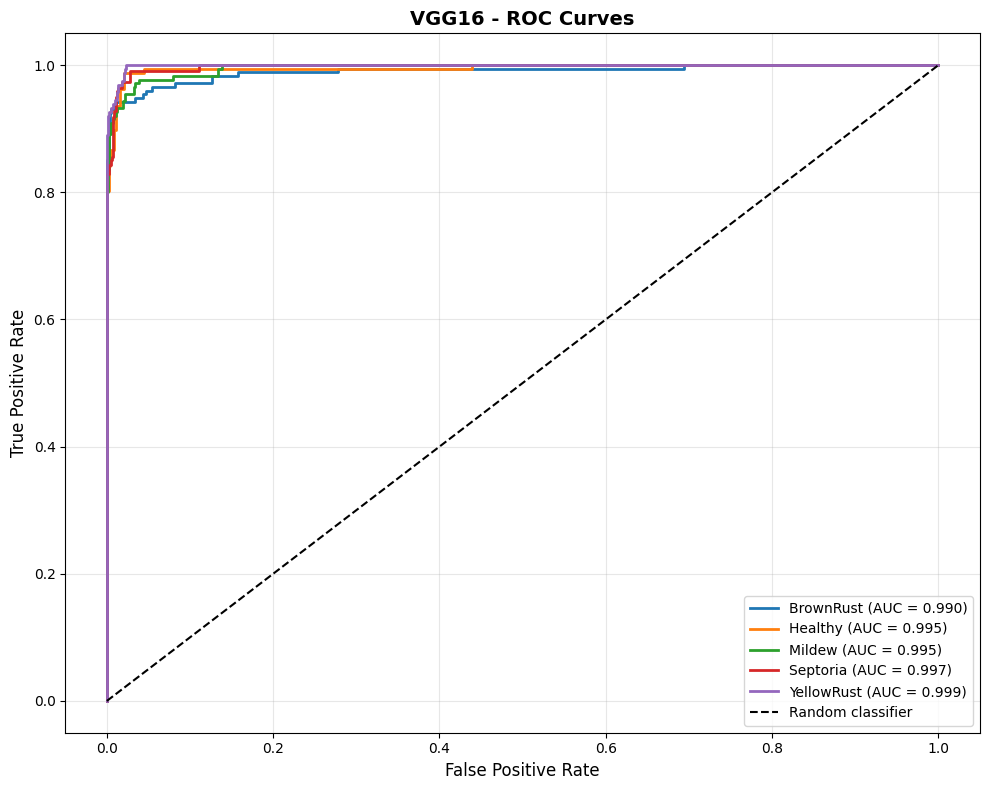

In [54]:
# VGG16 - ROC Curve (multiclass)
from pathlib import Path
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

if 'saved_paths' not in globals():
    ARTIFACTS_DIR = Path('artifacts')
    saved_paths = {
        'VGG16': ARTIFACTS_DIR / 'VGG16_best.keras' if (ARTIFACTS_DIR / 'VGG16_best.keras').exists() else ARTIFACTS_DIR / 'VGG16.keras',
        'MobileNetV2': ARTIFACTS_DIR / 'MobileNetV2_best.keras' if (ARTIFACTS_DIR / 'MobileNetV2_best.keras').exists() else ARTIFACTS_DIR / 'MobileNetV2.keras',
        'ResNet50': ARTIFACTS_DIR / 'ResNet50_best.keras' if (ARTIFACTS_DIR / 'ResNet50_best.keras').exists() else ARTIFACTS_DIR / 'ResNet50.keras',
        'DenseNet121': ARTIFACTS_DIR / 'DenseNet121_best.keras' if (ARTIFACTS_DIR / 'DenseNet121_best.keras').exists() else ARTIFACTS_DIR / 'DenseNet121.keras',
    }
    saved_path = saved_paths

# If y_prob_vgg has not been computed yet, load the model and compute predictions
if 'y_prob_vgg' not in globals():
    vgg_model_roc = tf.keras.models.load_model(saved_paths['VGG16'])
    y_prob_vgg = vgg_model_roc.predict(test_ds, verbose=0)

if 'y_true' not in globals():
    y_true = np.asarray(test_labels)

num_classes = len(class_names)
y_true_bin = label_binarize(y_true, classes=np.arange(num_classes))

# Plot ROC curve for each disease class
plt.figure(figsize=(10, 8))

for i, class_name in enumerate(class_names):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob_vgg[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{class_name} (AUC = {roc_auc:.3f})"
    )

# Random-classifier reference line
plt.plot([0, 1], [0, 1], "k--", label="Random classifier")
plt.title("VGG16 - ROC Curves", fontsize=14, fontweight='bold')
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

28/28 ━━━━━━━━━━━━━━━━━━━━ 28s 926ms/step


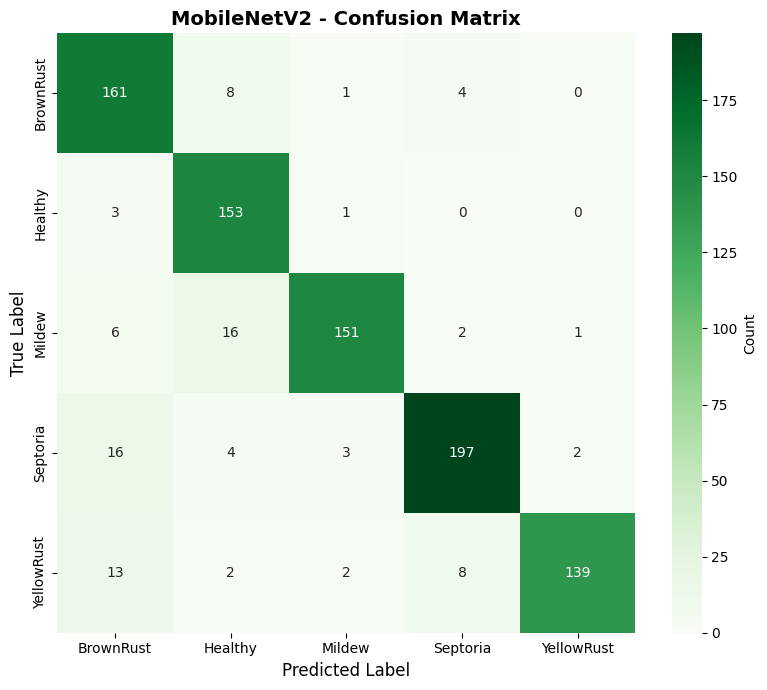

MobileNetV2 - Classification Report:
              precision    recall  f1-score   support

   BrownRust       0.81      0.93      0.86       174
     Healthy       0.84      0.97      0.90       157
      Mildew       0.96      0.86      0.90       176
    Septoria       0.93      0.89      0.91       222
  YellowRust       0.98      0.85      0.91       164

    accuracy                           0.90       893
   macro avg       0.90      0.90      0.90       893
weighted avg       0.90      0.90      0.90       893



In [55]:
# MobileNetV2 Confusion Matrix
mobile_model_cm = tf.keras.models.load_model(saved_paths['MobileNetV2'])
y_prob_mobile = mobile_model_cm.predict(test_ds)
y_pred_mobile = np.argmax(y_prob_mobile, axis=1)
y_true = np.array(test_labels)

cm_mobile = confusion_matrix(y_true, y_pred_mobile)
plt.figure(figsize=(8, 7))
sns.heatmap(cm_mobile, annot=True, fmt='d', cmap='Greens', xticklabels=class_names, yticklabels=class_names, cbar_kws={'label': 'Count'})
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('MobileNetV2 - Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("MobileNetV2 - Classification Report:")
print(classification_report(y_true, y_pred_mobile, target_names=class_names, zero_division=0))

28/28 ━━━━━━━━━━━━━━━━━━━━ 58s 2s/step


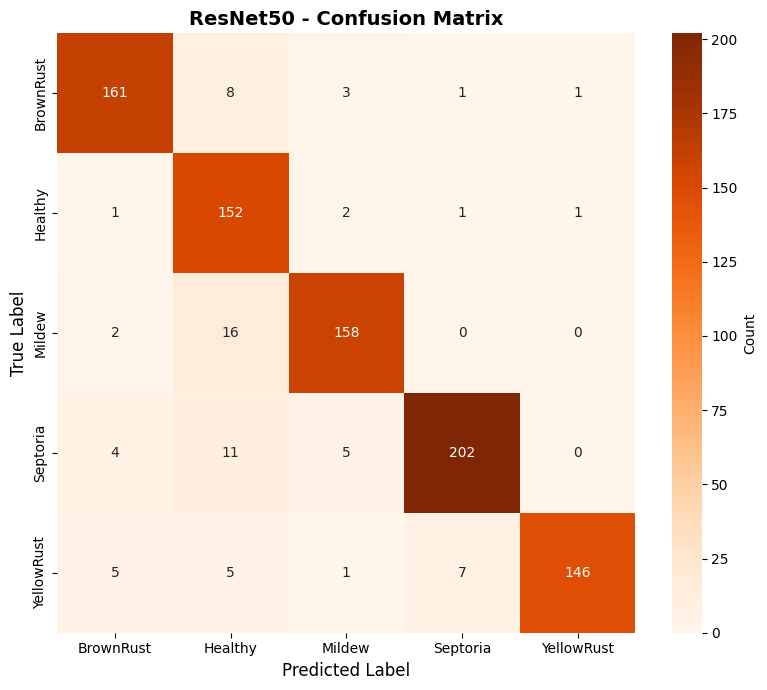

ResNet50 - Classification Report:
              precision    recall  f1-score   support

   BrownRust       0.93      0.93      0.93       174
     Healthy       0.79      0.97      0.87       157
      Mildew       0.93      0.90      0.92       176
    Septoria       0.96      0.91      0.93       222
  YellowRust       0.99      0.89      0.94       164

    accuracy                           0.92       893
   macro avg       0.92      0.92      0.92       893
weighted avg       0.92      0.92      0.92       893



In [56]:
# ResNet50 Confusion Matrix
resnet_model_cm = tf.keras.models.load_model(saved_paths['ResNet50'])
y_prob_resnet = resnet_model_cm.predict(test_ds)
y_pred_resnet = np.argmax(y_prob_resnet, axis=1)
y_true = np.array(test_labels)

cm_resnet = confusion_matrix(y_true, y_pred_resnet)
plt.figure(figsize=(8, 7))
sns.heatmap(cm_resnet, annot=True, fmt='d', cmap='Oranges', xticklabels=class_names, yticklabels=class_names, cbar_kws={'label': 'Count'})
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('ResNet50 - Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("ResNet50 - Classification Report:")
print(classification_report(y_true, y_pred_resnet, target_names=class_names, zero_division=0))


In [57]:
def predict_image(path, model, class_names):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32)
    img = tf.expand_dims(img, axis=0)
    preds = model.predict(img)
    idx = int(np.argmax(preds[0]))
    return class_names[idx], float(preds[0][idx])

# Example usage:
# user_image_path = 'path/to/your/image.jpg'
# label, confidence = predict_image(user_image_path, best_model, class_names)
# print(label, confidence)


In [58]:
# Predict a held-out image using the evaluated ResNet50 model.
resnet_model = tf.keras.models.load_model(saved_paths['ResNet50'])
user_image_path = test_paths[0]
label, confidence = predict_image(user_image_path, resnet_model, class_names)
print(label, confidence)


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Septoria 0.9067736268043518


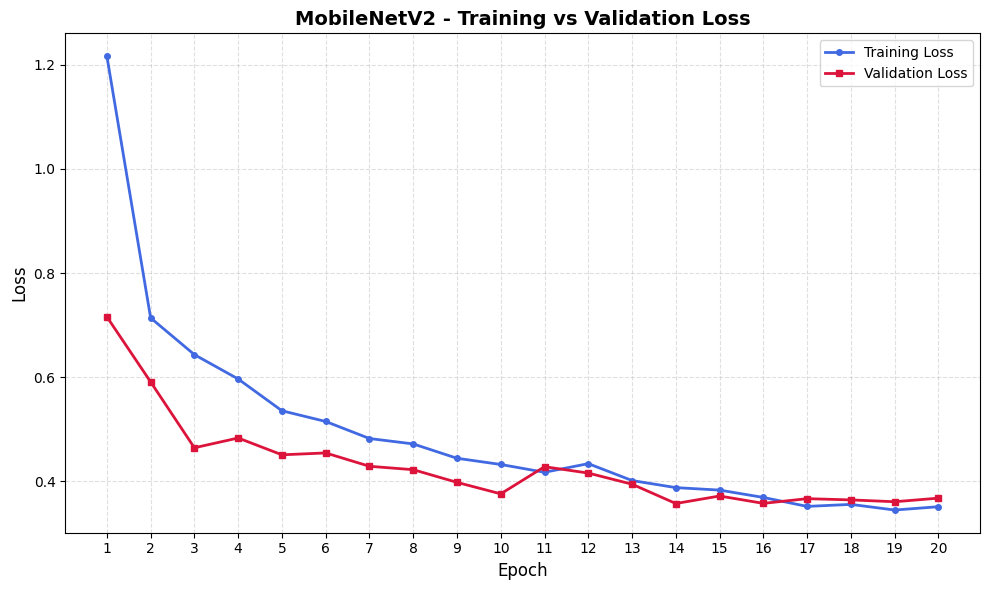

In [59]:
# MobileNetV2 - Training vs Validation Loss
mobile_hist = histories['MobileNetV2'].history
epochs_mobile = range(1, len(mobile_hist['loss']) + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs_mobile, mobile_hist['loss'], color='royalblue', marker='o', markersize=4, linewidth=2, label='Training Loss')
plt.plot(epochs_mobile, mobile_hist['val_loss'], color='crimson', marker='s', markersize=4, linewidth=2, label='Validation Loss')
plt.title('MobileNetV2 - Training vs Validation Loss', fontsize=14, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.xticks(range(1, len(mobile_hist['loss']) + 1))
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

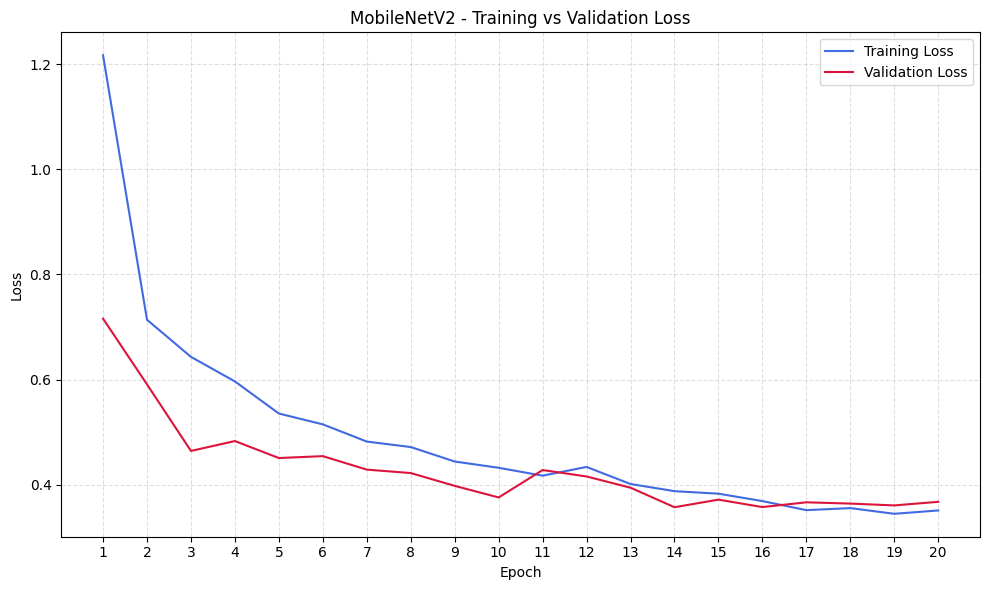

In [61]:
# MobileNetV2 - Training vs Validation Loss
if 'MobileNetV2' not in histories:
    raise ValueError("MobileNetV2 has not been trained yet. Run the training cell first.")

mobile_hist = histories['MobileNetV2'].history
epochs_mobile = range(1, len(mobile_hist['loss']) + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs_mobile, mobile_hist['loss'], label='Training Loss', color='royalblue')
plt.plot(epochs_mobile, mobile_hist['val_loss'], label='Validation Loss', color='crimson')

plt.title('MobileNetV2 - Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.xticks(range(1, len(mobile_hist['loss']) + 1))
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

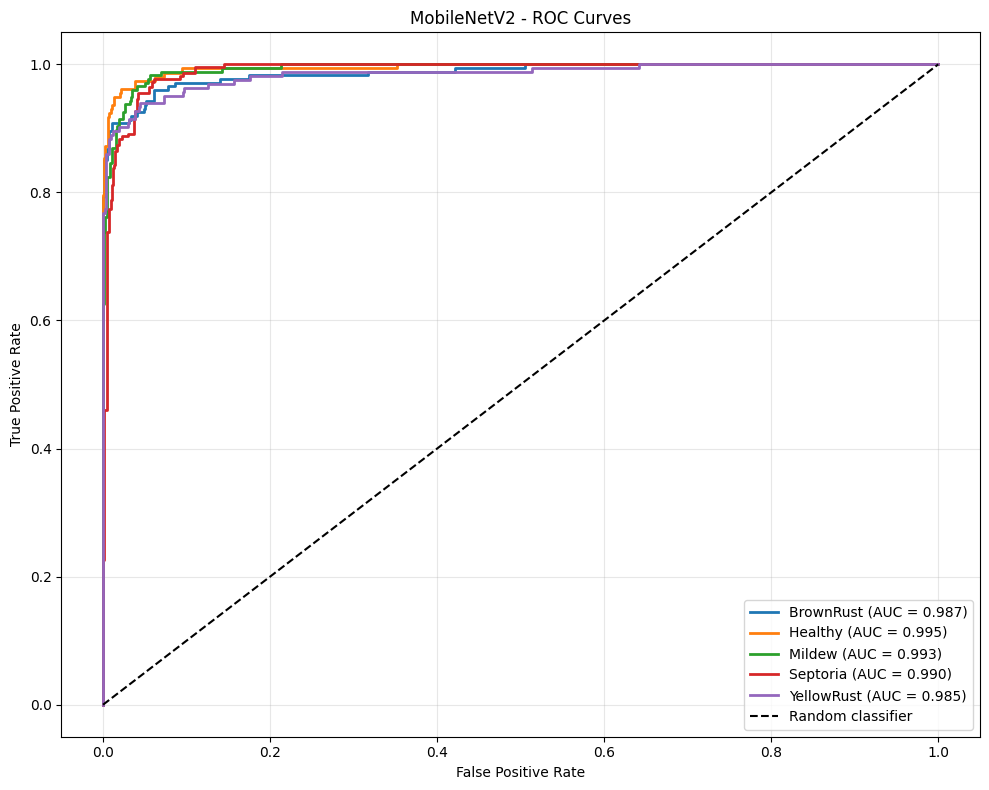

In [63]:
# MobileNetV2 - ROC Curve (multiclass)
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

# Load the best MobileNetV2 model
mobile_model = tf.keras.models.load_model(saved_paths["MobileNetV2"])

# Get predicted class probabilities
y_prob_mobile = mobile_model.predict(test_ds, verbose=0)

# True labels and one-hot/binary representation
y_true = np.asarray(test_labels)
num_classes = len(class_names)
y_true_bin = label_binarize(y_true, classes=np.arange(num_classes))

# Plot ROC curve for each disease class
plt.figure(figsize=(10, 8))

for i, class_name in enumerate(class_names):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob_mobile[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{class_name} (AUC = {roc_auc:.3f})"
    )

# Random-classifier reference line
plt.plot([0, 1], [0, 1], "k--", label="Random classifier")

plt.title("MobileNetV2 - ROC Curves")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

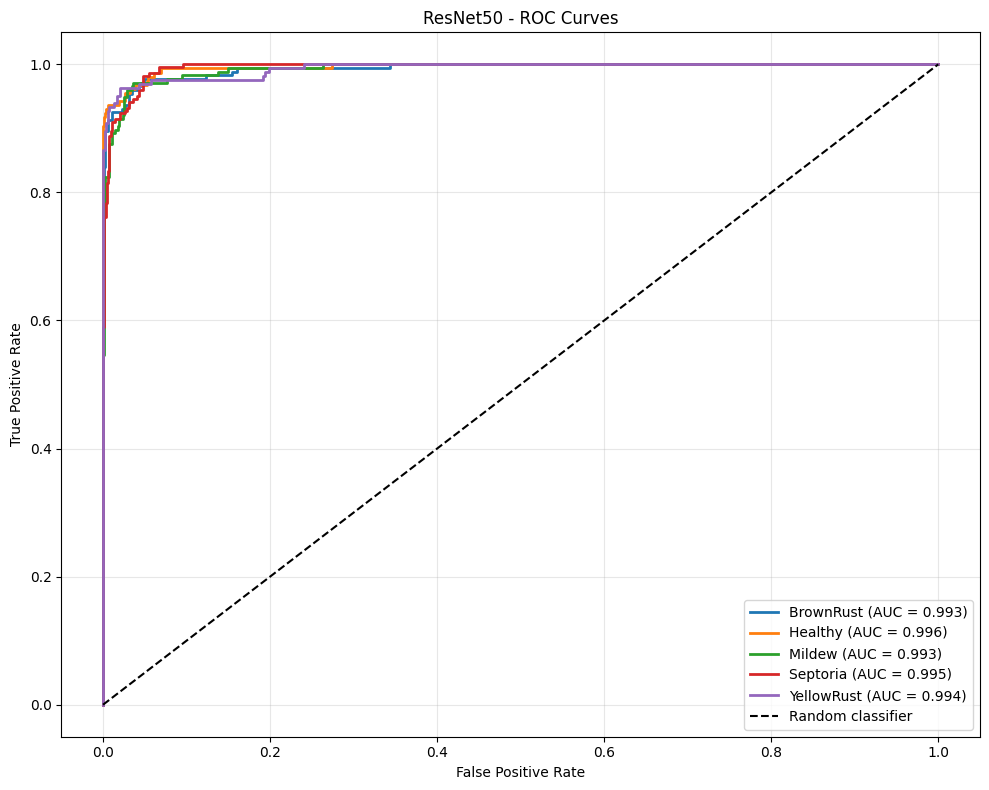

In [64]:
# ResNet50 - ROC Curve (multiclass)
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

# Load the best trained ResNet50 model
resnet_model = tf.keras.models.load_model(saved_paths["ResNet50"])

# Get class probabilities for the test images
y_prob_resnet = resnet_model.predict(test_ds, verbose=0)

# Convert true numeric labels to one-vs-rest binary labels
y_true = np.asarray(test_labels)
num_classes = len(class_names)
y_true_bin = label_binarize(y_true, classes=np.arange(num_classes))

# Plot one ROC curve per class
plt.figure(figsize=(10, 8))

for i, class_name in enumerate(class_names):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob_resnet[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{class_name} (AUC = {roc_auc:.3f})"
    )

# Random classifier baseline
plt.plot([0, 1], [0, 1], "k--", label="Random classifier")

plt.title("ResNet50 - ROC Curves")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

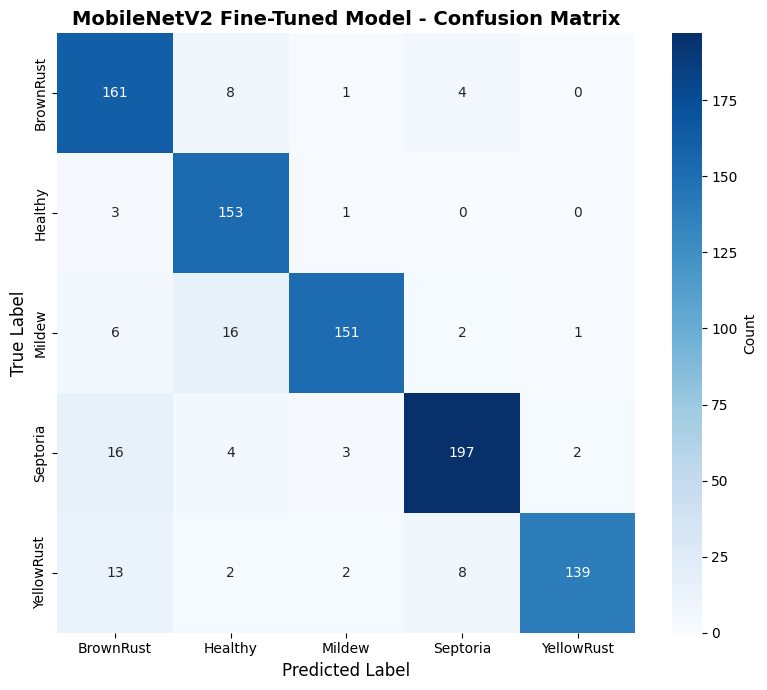

MobileNetV2 Fine-Tuned Model - Classification Report:
              precision    recall  f1-score   support

   BrownRust       0.81      0.93      0.86       174
     Healthy       0.84      0.97      0.90       157
      Mildew       0.96      0.86      0.90       176
    Septoria       0.93      0.89      0.91       222
  YellowRust       0.98      0.85      0.91       164

    accuracy                           0.90       893
   macro avg       0.90      0.90      0.90       893
weighted avg       0.90      0.90      0.90       893



In [65]:
# MobileNetV2 Fine-Tuned Model - Confusion Matrix
# This evaluates the best checkpoint saved during the fine-tuning stage.
mobilenet_fine_tuned_path = ARTIFACTS_DIR / 'MobileNetV2_best.keras'
if not mobilenet_fine_tuned_path.exists():
    raise FileNotFoundError(
        f'Fine-tuned MobileNetV2 checkpoint not found: {mobilenet_fine_tuned_path}. Run fine-tuning first.'
    )

mobilenet_fine_tuned_model = tf.keras.models.load_model(mobilenet_fine_tuned_path)
y_prob_mobilenet_finetuned = mobilenet_fine_tuned_model.predict(test_ds, verbose=0)
y_pred_mobilenet_finetuned = np.argmax(y_prob_mobilenet_finetuned, axis=1)
y_true_mobilenet_finetuned = np.asarray(test_labels)

cm_mobilenet_finetuned = confusion_matrix(
    y_true_mobilenet_finetuned, y_pred_mobilenet_finetuned
)
plt.figure(figsize=(8, 7))
sns.heatmap(
    cm_mobilenet_finetuned, annot=True, fmt='d', cmap='Blues',
    xticklabels=class_names, yticklabels=class_names, cbar_kws={'label': 'Count'}
)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('MobileNetV2 Fine-Tuned Model - Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('MobileNetV2 Fine-Tuned Model - Classification Report:')
print(classification_report(
    y_true_mobilenet_finetuned, y_pred_mobilenet_finetuned,
    target_names=class_names, zero_division=0
))


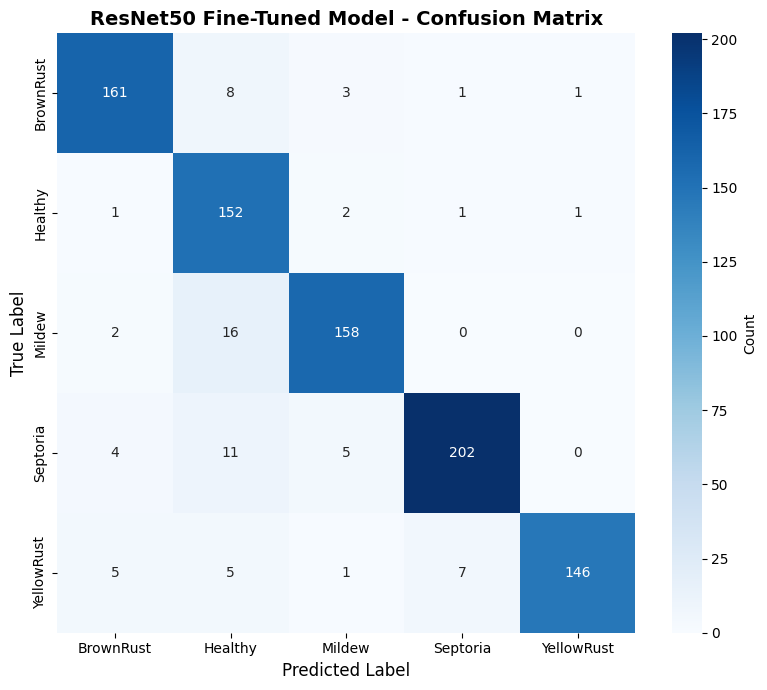

ResNet50 Fine-Tuned Model - Classification Report:
              precision    recall  f1-score   support

   BrownRust       0.93      0.93      0.93       174
     Healthy       0.79      0.97      0.87       157
      Mildew       0.93      0.90      0.92       176
    Septoria       0.96      0.91      0.93       222
  YellowRust       0.99      0.89      0.94       164

    accuracy                           0.92       893
   macro avg       0.92      0.92      0.92       893
weighted avg       0.92      0.92      0.92       893



In [66]:
# ResNet50 Fine-Tuned Model - Confusion Matrix
# This evaluates the best checkpoint saved during the fine-tuning stage.
resnet_fine_tuned_path = ARTIFACTS_DIR / 'ResNet50_best.keras'
if not resnet_fine_tuned_path.exists():
    raise FileNotFoundError(
        f'Fine-tuned ResNet50 checkpoint not found: {resnet_fine_tuned_path}. Run fine-tuning first.'
    )

resnet_fine_tuned_model = tf.keras.models.load_model(resnet_fine_tuned_path)
y_prob_resnet_finetuned = resnet_fine_tuned_model.predict(test_ds, verbose=0)
y_pred_resnet_finetuned = np.argmax(y_prob_resnet_finetuned, axis=1)
y_true_resnet_finetuned = np.asarray(test_labels)

cm_resnet_finetuned = confusion_matrix(
    y_true_resnet_finetuned, y_pred_resnet_finetuned
)
plt.figure(figsize=(8, 7))
sns.heatmap(
    cm_resnet_finetuned, annot=True, fmt='d', cmap='Blues',
    xticklabels=class_names, yticklabels=class_names, cbar_kws={'label': 'Count'}
)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('ResNet50 Fine-Tuned Model - Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('ResNet50 Fine-Tuned Model - Classification Report:')
print(classification_report(
    y_true_resnet_finetuned, y_pred_resnet_finetuned,
    target_names=class_names, zero_division=0
))


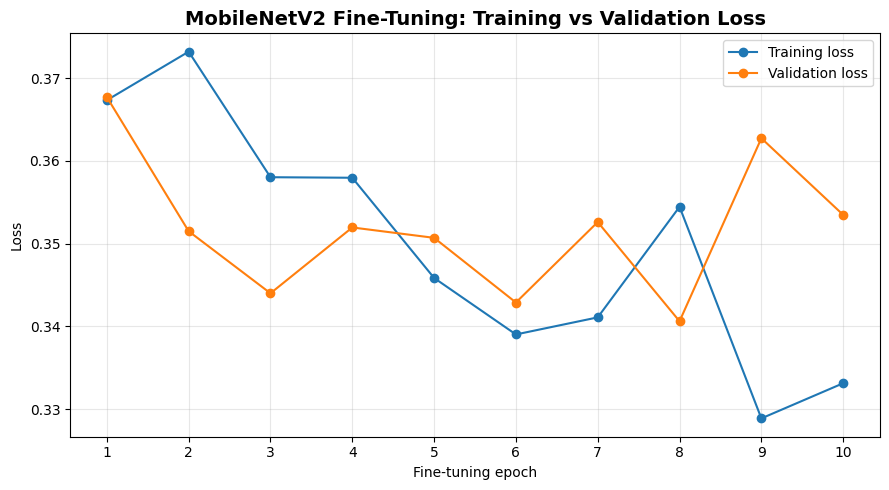

In [67]:
# MobileNetV2 Fine-Tuning: Training vs Validation Loss
if 'fine_tune_histories' not in globals() or 'MobileNetV2' not in fine_tune_histories:
    raise RuntimeError(
        'MobileNetV2 fine-tuning history is unavailable. Run the training cell with fine-tuning enabled first.'
    )

mobilenet_finetune_history = fine_tune_histories['MobileNetV2'].history
epochs_mobilenet_finetuned = range(1, len(mobilenet_finetune_history['loss']) + 1)

plt.figure(figsize=(9, 5))
plt.plot(epochs_mobilenet_finetuned, mobilenet_finetune_history['loss'], marker='o', label='Training loss')
plt.plot(epochs_mobilenet_finetuned, mobilenet_finetune_history['val_loss'], marker='o', label='Validation loss')
plt.title('MobileNetV2 Fine-Tuning: Training vs Validation Loss', fontsize=14, fontweight='bold')
plt.xlabel('Fine-tuning epoch')
plt.ylabel('Loss')
plt.xticks(list(epochs_mobilenet_finetuned))
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


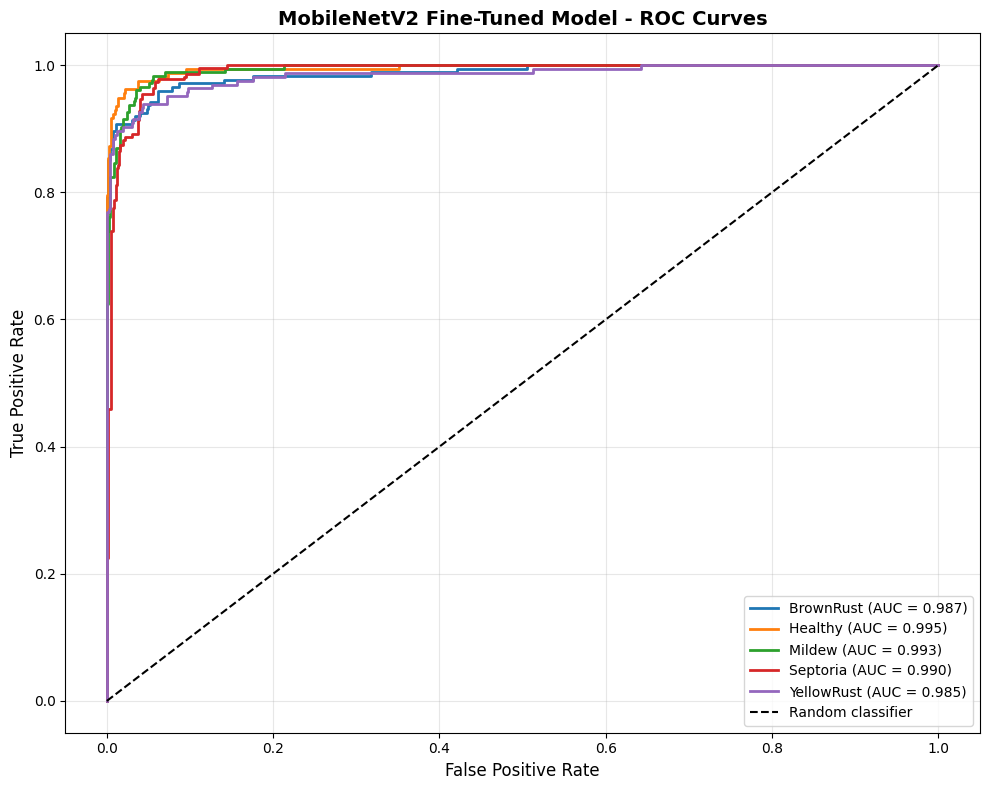

In [68]:
# MobileNetV2 Fine-Tuned Model - ROC Curves (multiclass)
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

mobilenet_fine_tuned_roc_path = ARTIFACTS_DIR / 'MobileNetV2_best.keras'
if not mobilenet_fine_tuned_roc_path.exists():
    raise FileNotFoundError(
        f'Fine-tuned MobileNetV2 checkpoint not found: {mobilenet_fine_tuned_roc_path}. Run fine-tuning first.'
    )

mobilenet_fine_tuned_roc_model = tf.keras.models.load_model(mobilenet_fine_tuned_roc_path)
y_prob_mobilenet_finetuned = mobilenet_fine_tuned_roc_model.predict(test_ds, verbose=0)
y_true_mobilenet_finetuned = np.asarray(test_labels)
num_classes = len(class_names)
y_true_mobilenet_finetuned_bin = label_binarize(
    y_true_mobilenet_finetuned, classes=np.arange(num_classes)
)

plt.figure(figsize=(10, 8))
for i, class_name in enumerate(class_names):
    fpr, tpr, _ = roc_curve(
        y_true_mobilenet_finetuned_bin[:, i], y_prob_mobilenet_finetuned[:, i]
    )
    plt.plot(fpr, tpr, linewidth=2, label=f'{class_name} (AUC = {auc(fpr, tpr):.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random classifier')
plt.title('MobileNetV2 Fine-Tuned Model - ROC Curves', fontsize=14, fontweight='bold')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


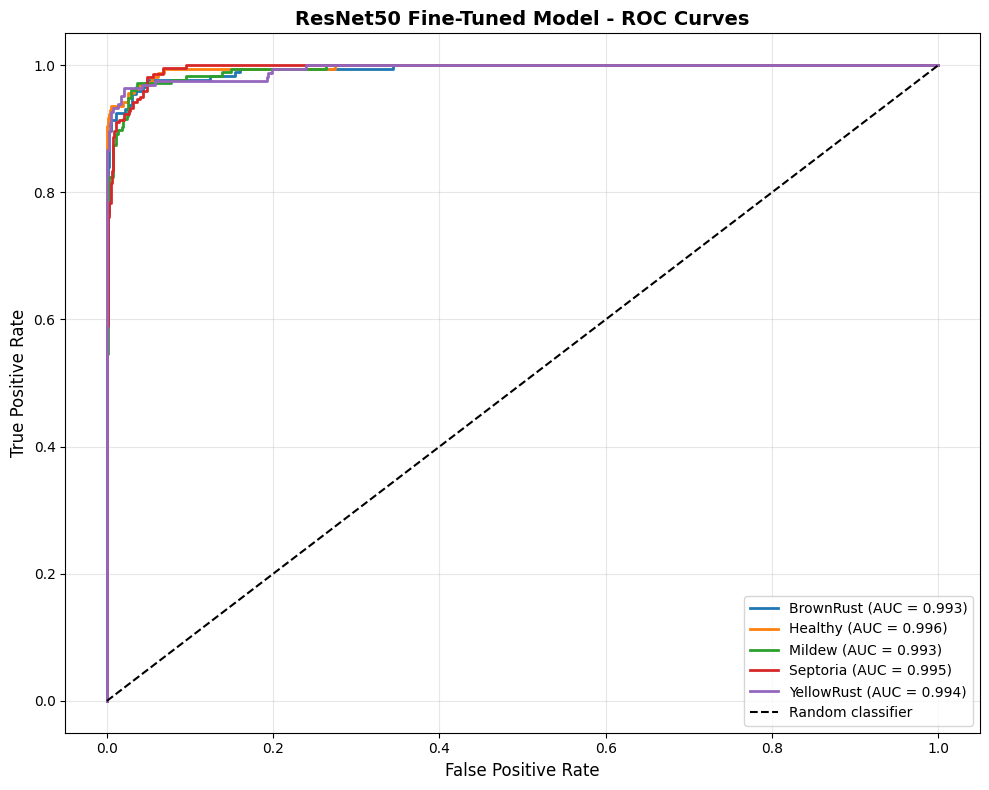

In [69]:
# ResNet50 Fine-Tuned Model - ROC Curves (multiclass)
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

resnet_fine_tuned_roc_path = ARTIFACTS_DIR / 'ResNet50_best.keras'
if not resnet_fine_tuned_roc_path.exists():
    raise FileNotFoundError(
        f'Fine-tuned ResNet50 checkpoint not found: {resnet_fine_tuned_roc_path}. Run fine-tuning first.'
    )

resnet_fine_tuned_roc_model = tf.keras.models.load_model(resnet_fine_tuned_roc_path)
y_prob_resnet_finetuned = resnet_fine_tuned_roc_model.predict(test_ds, verbose=0)
y_true_resnet_finetuned = np.asarray(test_labels)
num_classes = len(class_names)
y_true_resnet_finetuned_bin = label_binarize(
    y_true_resnet_finetuned, classes=np.arange(num_classes)
)

plt.figure(figsize=(10, 8))
for i, class_name in enumerate(class_names):
    fpr, tpr, _ = roc_curve(
        y_true_resnet_finetuned_bin[:, i], y_prob_resnet_finetuned[:, i]
    )
    plt.plot(fpr, tpr, linewidth=2, label=f'{class_name} (AUC = {auc(fpr, tpr):.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random classifier')
plt.title('ResNet50 Fine-Tuned Model - ROC Curves', fontsize=14, fontweight='bold')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [70]:
import numpy as np
import tensorflow as tf

targets = np.eye(len(class_names))[np.asarray(test_labels, dtype=int)]

for name in ["VGG16", "MobileNetV2", "ResNet50"]:
    print(f"Calculating {name}...", flush=True)
    model_rmse = tf.keras.models.load_model(
        f"artifacts/{name}_best.keras", compile=False
    )
    probabilities = model_rmse.predict(test_ds, verbose=1)
    rmse = np.sqrt(np.mean((probabilities - targets) ** 2))
    print(f"{name} probability RMSE: {rmse:.6f}", flush=True)

Calculating VGG16...
28/28 ━━━━━━━━━━━━━━━━━━━━ 68s 2s/step
VGG16 probability RMSE: 0.140130
Calculating MobileNetV2...
28/28 ━━━━━━━━━━━━━━━━━━━━ 28s 921ms/step
MobileNetV2 probability RMSE: 0.170346
Calculating ResNet50...
28/28 ━━━━━━━━━━━━━━━━━━━━ 57s 2s/step
ResNet50 probability RMSE: 0.155884
